# Rock, Paper, Scissors Classification Model
- 3 classes/poses: rock, paper, scissors
  - 1 sample has 5 * 6  features (for now)?
- Classification neural net

https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/02_pytorch_classification.ipynb#scrollTo=Z2gcR31aHC78

In [61]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn

In [62]:
print(torch.__version__)
print(torch._dynamo.__file__)

2.6.0+cu124
/mnt/c/Users/j15t3/Documents/Programming/Capstone/.venv/lib/python3.12/site-packages/torch/_dynamo/__init__.py


## Ablation

https://docs.google.com/spreadsheets/d/1Xy92hWhrxcyvLkxY7Q0RPff1FNVfsLxV0ujrjC6SdFE/edit?gid=427952541#gid=427952541

In [63]:
EPOCHS = 500
STD = 0.03
COPY = 4
HIDDEN = 0 # No consistent hidden layers in other models
DROPOUT = 0.5

N_FOLDS = 5

In [64]:
# os.chdir("/content/drive/MyDrive/Senior/Capstone/new data")
df = pd.read_csv("data/Glove_v2/output.csv")
# df = pd.read_csv("jag_RPS_training_data.csv")
df.head()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22683 entries, 0 to 22682
Data columns (total 50 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       22683 non-null  float64
 1   1       22683 non-null  float64
 2   2       22683 non-null  float64
 3   3       22683 non-null  float64
 4   4       22683 non-null  float64
 5   5       22683 non-null  float64
 6   6       22683 non-null  float64
 7   7       22683 non-null  float64
 8   8       22683 non-null  float64
 9   9       22683 non-null  float64
 10  10      22683 non-null  float64
 11  11      22683 non-null  float64
 12  12      22683 non-null  float64
 13  13      22683 non-null  float64
 14  14      22683 non-null  float64
 15  15      22683 non-null  float64
 16  16      22683 non-null  float64
 17  17      22683 non-null  float64
 18  18      22683 non-null  float64
 19  19      22683 non-null  float64
 20  20      22683 non-null  float64
 21  21      22683 non-null  float64
 22  22      2

In [65]:
def augment_with_noise(df, label_col="label", noise_std=0.01, copies=3):
    feature_cols = df.drop(columns=[label_col]).columns
    augmented_dfs = [df]  # keep original

    for i in range(copies):

        noisy_df = df.copy()

        noise = np.random.normal(
            loc=0,
            scale=noise_std,
            size=noisy_df[feature_cols].shape
        )

        noisy_df[feature_cols] = noisy_df[feature_cols] + noise

        augmented_dfs.append(noisy_df)

    return pd.concat(augmented_dfs, ignore_index=True)

In [107]:
augmented_df = augment_with_noise(
    df,
    label_col="label",
    noise_std=STD,   # adjust noise strength
    copies=COPY
)

print(len(df))
df = augmented_df
print(len(augmented_df))

21683
108415


In [67]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,label
0,0.000349,-0.216,0.935,-0.346,-6.155,12.869,-7.498,0.099,-0.480,0.190,...,3.053,1.191,-0.122,0.967,-0.066,-0.511,-7.634,-2.962,1.450,paper
1,0.000443,-0.228,0.919,-0.315,-1.902,14.660,-7.274,0.099,-0.480,0.190,...,4.244,0.855,0.061,0.945,-0.070,-0.531,-5.634,-4.229,0.901,paper
2,0.000521,-0.146,0.907,-0.440,-1.343,27.865,-11.191,0.109,-0.516,0.189,...,5.740,0.336,-0.550,0.939,-0.068,-0.516,-4.794,-4.947,0.122,paper
3,0.000595,-0.146,0.907,-0.440,-0.112,0.000,-1.567,0.134,-0.551,0.168,...,6.153,0.183,-1.481,0.954,-0.067,-0.509,-4.779,-4.763,-1.252,paper
4,0.002183,-0.021,0.892,-0.358,0.112,1.679,-0.448,0.131,-0.565,0.189,...,6.076,0.366,-1.847,0.959,-0.065,-0.496,-5.527,-4.305,-1.237,paper


In [109]:
# 1. Get your minimum count
min_count = df['label'].value_counts().min()

# 2. Use groupby + sample directly (much more reliable)
df_balanced = (
    df.groupby('label', group_keys=False)
    .sample(n=min_count, random_state=42)
)

# 3. Reset index at the very end
df_balanced = df_balanced.reset_index(drop=True)

# Now this will work
print(df_balanced['label'].value_counts())
df = df_balanced

label
none        3585
paper       3585
rock        3585
scissors    3585
Name: count, dtype: int64


In [110]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,label
0,18.805977,0.302849,0.926801,-0.186143,-1.235425,0.287980,0.797394,-0.023483,-0.417434,-0.024488,...,4.860056,-0.422116,-2.396158,0.819361,0.188764,-0.771599,-6.036721,-5.773011,-1.546840,none
1,17.772720,0.350054,0.902732,-0.156598,0.569181,-0.761436,0.781223,-0.067762,-0.445074,-0.042167,...,4.104468,0.505023,-1.652187,0.701217,0.243655,-0.772808,-6.686661,-4.279994,-0.932764,none
2,15.758953,0.337122,0.871829,-0.140743,-0.402453,-0.469172,-0.475538,-0.092026,-0.414776,-0.050316,...,5.609926,-0.332519,-1.112925,0.787141,0.284830,-0.747293,-5.384340,-5.225673,-0.629719,none
3,14.709059,0.318000,0.885000,-0.164000,1.567000,-1.679000,-0.895000,-0.084000,-0.429000,-0.044000,...,5.496000,1.328000,-1.069000,0.733000,0.257000,-0.762000,-5.725000,-3.969000,-0.489000,none
4,58.694863,0.302228,0.889371,-0.275374,1.365359,0.951019,-0.429147,-0.096783,-0.405145,-0.061918,...,5.887841,1.361632,-1.199466,0.718929,0.246826,-0.810587,-5.077630,-3.846718,-0.825928,none


In [111]:
# testing = df.sample(n=1000)
testing = df.sample(n=1000, random_state=42).sort_values(by='label').reset_index(drop=True)
df      = df.drop(testing.index).reset_index(drop=True)
testing = testing.reset_index(drop=True)

print(f"testing: {testing.shape}")
print(f"df:      {df.shape}")

testing: (1000, 50)
df:      (13340, 50)


In [112]:
df_all = df
df_all.label.value_counts()

label
paper       3585
rock        3585
scissors    3585
none        2585
Name: count, dtype: int64

## Make data and label dfs


In [113]:
# Scramble the rows
df_all = df_all.sample(frac=1).reset_index(drop=True)
# df_all = df_all.drop(columns=["time"])
df_all.head(3)

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,label
0,22.334373,-0.357000,0.857000,-0.366000,-23.612000,-25.850000,-16.898000,0.047000,-0.282000,0.212000,...,-14.794000,-23.603000,17.679000,1.025000,-0.11100,0.293000,-24.824000,-25.23700,23.267000,rock
1,74.822874,0.057000,0.717000,-0.319000,5.707000,3.693000,-14.883000,-0.021000,-0.335000,-0.027000,...,8.748000,4.992000,3.863000,0.844000,-0.38600,0.436000,-3.756000,3.13000,3.908000,scissors
2,60.674853,0.189247,0.357096,-0.967911,-36.860597,31.463336,-42.299236,0.029282,-0.328701,0.195294,...,61.695266,25.493759,15.695287,1.038437,-0.36241,-0.424225,53.622483,24.40811,-5.927561,scissors


In [114]:
# # Drop all gyro data
# gyro_cols = [col for col in df_all.columns if "gyro" in col]
# df_all = df_all.drop(columns=gyro_cols)
# # leaves you with 18 features (6 sensors × 3 axes)

In [115]:
labels = df_all["label"] # separate labels df, encode labels
mapping = {'rock': 0, 'paper': 1, 'scissors': 2, 'none' : 3}
labels = labels.map(mapping)
data = df_all.drop(columns=["label"])

In [116]:
# data into pytorch tensors
X = torch.from_numpy(data.values).type(torch.float)
y = torch.from_numpy(labels.values).type(torch.float)

# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Model

In [117]:
input_features = data.shape[1]
classes = len(mapping) # 3 or 4
hidden_units = HIDDEN
input_features

49

In [118]:
classes

4

In [119]:
# # MODEL 1
# class RPSModel(nn.Module):
#     def __init__(self, input_features, output_features):
#         super().__init__()
#         self.linear_layer_stack = nn.Sequential(
#             nn.Linear(in_features=input_features, out_features=hidden_units),
#             nn.Dropout(p=DROPOUT), # dropout probability
#             # nn.ReLU(),
#             # nn.Linear(in_features=32, out_features=32),
#             # nn.ReLU(),
#             nn.Linear(in_features=hidden_units, out_features=output_features),
#         )

#     # 3. Define a forward method containing the forward pass computation
#     def forward(self, x):
#         return self.linear_layer_stack(x)

In [120]:
# # MODEL 2
# class RPSModel(nn.Module):
#     def __init__(self, input_features, output_features):
#         super().__init__()
#         self.linear_layer_stack = nn.Sequential(
#             nn.Linear(in_features=input_features, out_features=64),
#             nn.BatchNorm1d(64),
#             nn.ReLU(),
#             nn.Dropout(p=DROPOUT),
#             nn.Linear(in_features=64, out_features=32),
#             nn.BatchNorm1d(32),
#             nn.ReLU(),
#             nn.Dropout(p=DROPOUT),

#             nn.Linear(in_features=32, out_features=3)
#         )

#     # 3. Define a forward method containing the forward pass computation
#     def forward(self, x):
#         return self.linear_layer_stack(x)

In [121]:
# MODEL 3
class RPSModel(nn.Module):
    def __init__(self, input_features, output_features):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=64),
            nn.LeakyReLU(),
            nn.Dropout(p=DROPOUT),

            nn.Linear(in_features=64, out_features=32),
            nn.LeakyReLU(),
            nn.Dropout(p=DROPOUT),

            nn.Linear(in_features=32, out_features=classes)
        )

    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        return self.linear_layer_stack(x)

In [122]:
# 4. Create an instance of the model and send it to target device
model_4 = RPSModel(input_features=input_features,
                    output_features=classes).to(device)

# Create a loss function
loss_fn = nn.CrossEntropyLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.1)

# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

#Training

In [123]:
# Generate a random integer between 1 and 100 (inclusive)
random_integer = random.randint(1, 100)
print(f"Random integer: {random_integer}")

Random integer: 40


In [124]:
# Add this right before your loss function
# print(f"Number of classes (logits shape): {y_logits.shape[1]}")
print(f"Max label value: {y_train.max()}")
print(f"Min label value: {y_train.min()}")

Max label value: 3.0
Min label value: 0.0


In [125]:
torch.manual_seed(24)

epochs = EPOCHS

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

y_train = y_train.long()
y_test = y_test.long()

# Track losses
train_losses, test_losses = [], []

for epoch in range(epochs):
    ### Training
    model_4.train()
    y_logits = model_4(X_train)
    y_pred = torch.argmax(y_logits, dim=1)
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(X_test)
        test_pred = torch.argmax(test_logits, dim=1)
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Record losses
    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 2.71038, Accuracy: 26.51% | Test loss: 1.42616, Test acc: 38.16%
Epoch: 10 | Loss: 1.33838, Accuracy: 37.40% | Test loss: 1.27468, Test acc: 44.19%
Epoch: 20 | Loss: 1.27660, Accuracy: 40.76% | Test loss: 1.22292, Test acc: 56.90%
Epoch: 30 | Loss: 1.23652, Accuracy: 43.51% | Test loss: 1.17997, Test acc: 61.02%
Epoch: 40 | Loss: 1.20812, Accuracy: 45.71% | Test loss: 1.13208, Test acc: 64.51%
Epoch: 50 | Loss: 1.17109, Accuracy: 48.80% | Test loss: 1.08699, Test acc: 66.42%
Epoch: 60 | Loss: 1.13605, Accuracy: 51.00% | Test loss: 1.04260, Test acc: 66.72%
Epoch: 70 | Loss: 1.11508, Accuracy: 53.75% | Test loss: 1.00563, Test acc: 68.14%
Epoch: 80 | Loss: 1.09338, Accuracy: 55.83% | Test loss: 0.97476, Test acc: 68.78%
Epoch: 90 | Loss: 1.06860, Accuracy: 57.24% | Test loss: 0.94864, Test acc: 69.60%
Epoch: 100 | Loss: 1.04316, Accuracy: 59.33% | Test loss: 0.92486, Test acc: 70.54%
Epoch: 110 | Loss: 1.03464, Accuracy: 60.34% | Test loss: 0.89908, Test acc: 71.63%
Epo

In [126]:
MODEL_PATH = "model_4_weights.pth"
torch.save(model_4.state_dict(), MODEL_PATH)


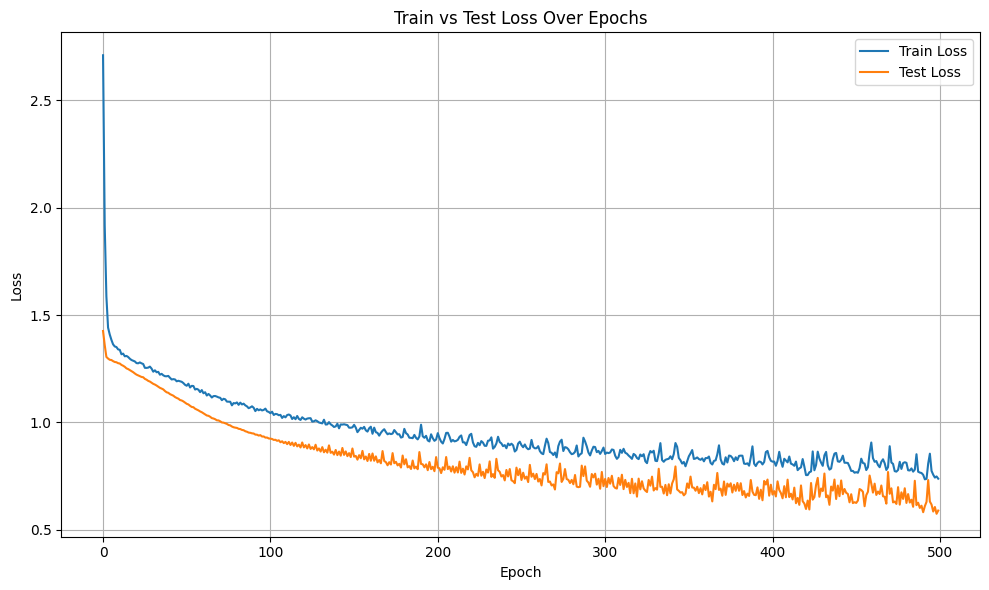

In [127]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Testing

In [128]:
testing["label"] = testing["label"].map(mapping)

cmap = plt.cm.get_cmap("gist_rainbow")
num_classes = len(mapping)
colors = cmap(np.linspace(0,1, len(labels)))
labels = ["Rock", "Paper", "Scissors"]

conf_thres = .7

/tmp/ipykernel_13146/1810967289.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("gist_rainbow")


In [129]:
# # Separate features and labels
true_labels = testing['label']
X_features = testing.copy()

X_features = X_features.drop(columns=['label']) # Drop label first

# Ensure all columns are numeric, coercing errors to NaN and filling NaNs with 0
for col in X_features.columns:
    X_features[col] = pd.to_numeric(X_features[col], errors='coerce')
X_features = X_features.fillna(0)

# Align columns with the training data's features
# This step should now work as X_features will have 39 columns (including gyro columns),
# matching the number of columns in `data`.
X_features = X_features[data.columns]

X_new = torch.tensor(X_features.values, dtype=torch.float32).to(device)

# Inference
model_4.eval()
with torch.inference_mode():
    new_logits = model_4(X_new)
    new_pred = torch.argmax(new_logits, dim=1)
    new_probs = torch.softmax(new_logits, dim=1)

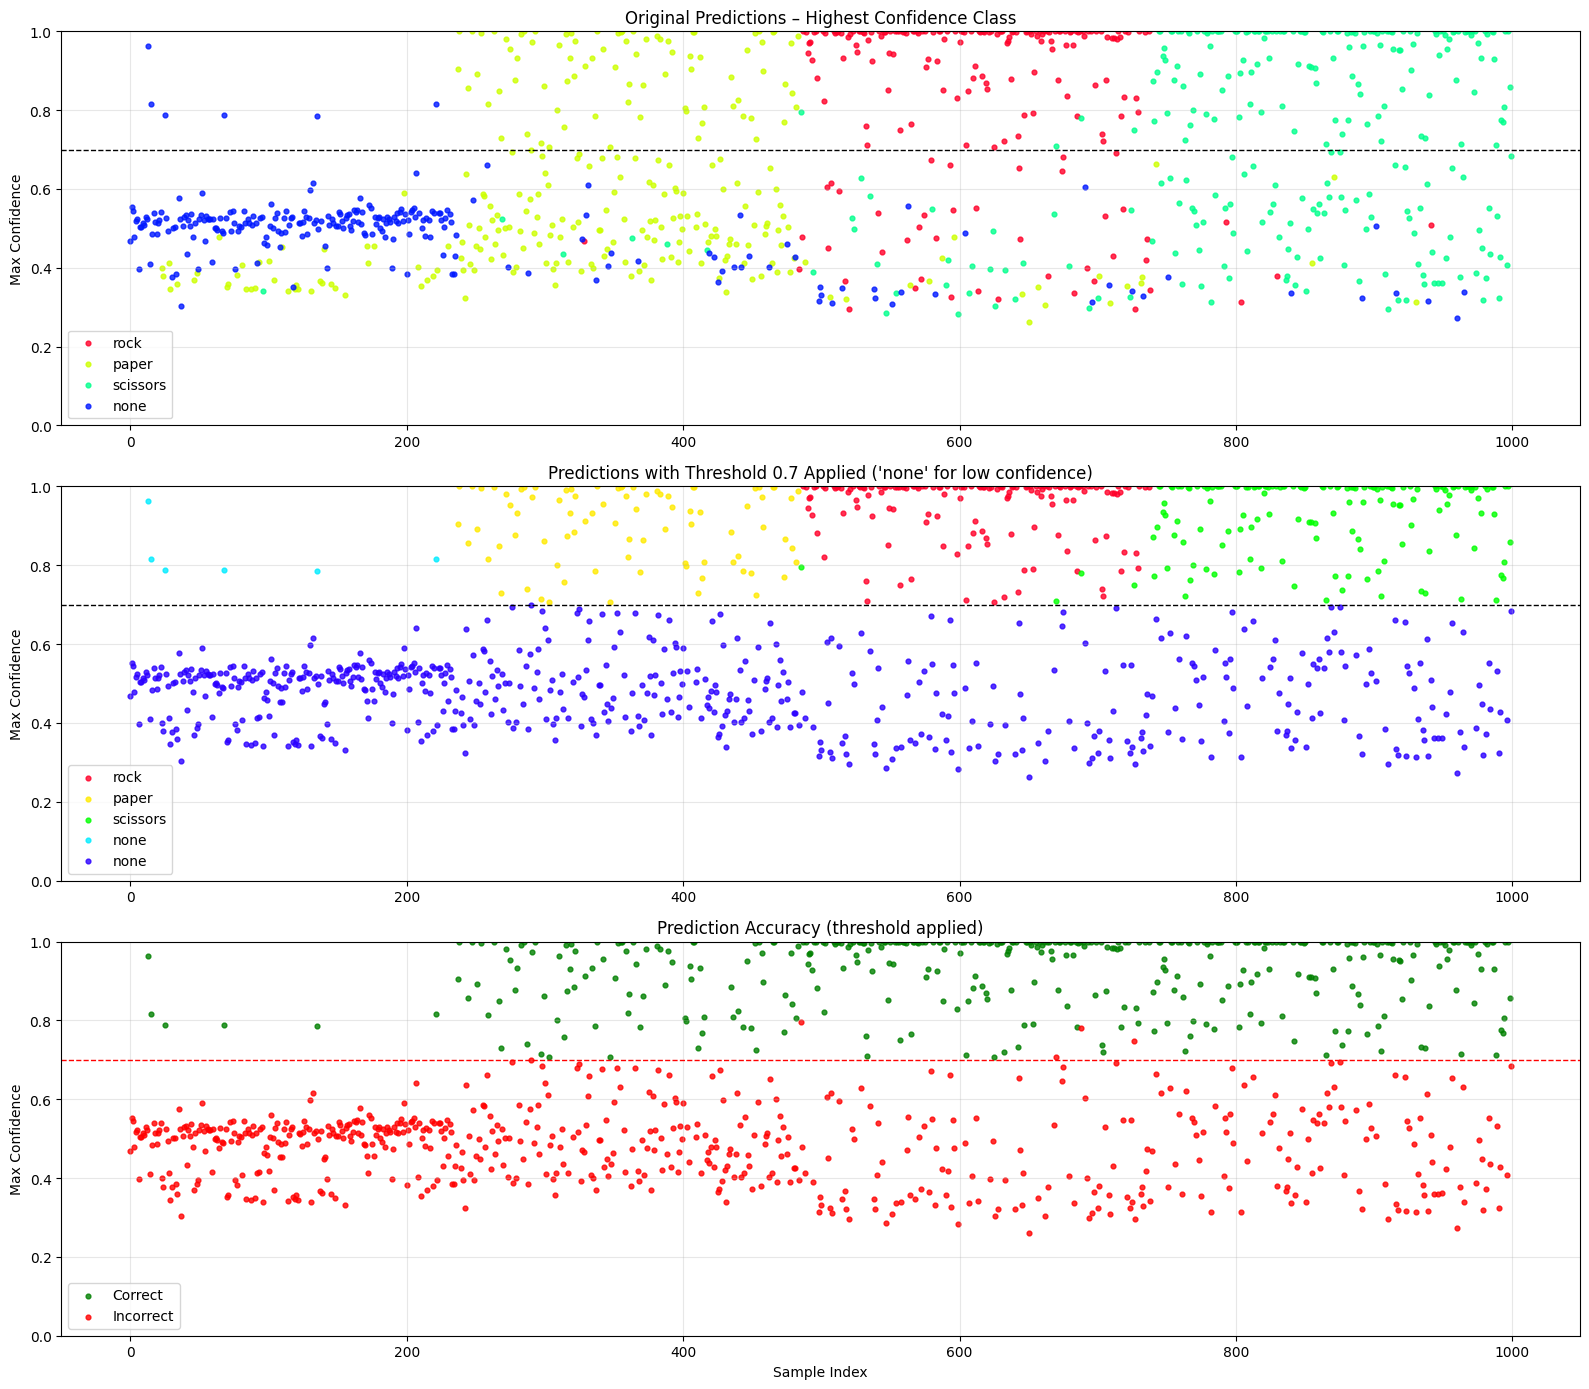

In [130]:
# ------------------------
# Prepare thresholded predictions
# ------------------------
# Convert tensors to CPU numpy
max_probs, max_classes = torch.max(new_probs, dim=1)
max_probs = max_probs.cpu().numpy()
max_classes = max_classes.cpu().numpy()
true_numeric = true_labels.reset_index(drop=True).values

pred_classes_thresh = max_classes.copy()
none_class_idx = len(mapping)  # new class index for "none"
pred_classes_thresh[max_probs < conf_thres] = none_class_idx

all_labels = list(mapping.keys()) + ['none']
num_classes = len(all_labels)

# ------------------------
# Create 3 subplots
# ------------------------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16,14))

# ------------------------
# Plot 1: Original max_classes (old graph)
# ------------------------
for class_idx, label in enumerate(mapping.keys()):
    mask = max_classes == class_idx
    indices = np.flatnonzero(mask)
    if len(indices) == 0:
        continue
    color = cmap(class_idx / len(mapping))
    ax1.scatter(
        indices,
        max_probs[indices],
        s=12,
        alpha=0.8,
        label=label,
        color=color
    )

ax1.set_ylabel("Max Confidence")
ax1.set_ylim(0,1)
ax1.set_title("Original Predictions – Highest Confidence Class")
ax1.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax1.legend()
ax1.grid(alpha=0.3)

# ------------------------
# Plot 2: Thresholded predictions (low confidence -> 'none')
# ------------------------
for class_idx, label in enumerate(all_labels):
    mask = pred_classes_thresh == class_idx
    indices = np.flatnonzero(mask)
    if len(indices) == 0:
        continue
    color = cmap(class_idx / num_classes)
    ax2.scatter(
        indices,
        max_probs[indices],
        s=12,
        alpha=0.8,
        label=label,
        color=color
    )

ax2.set_ylabel("Max Confidence")
ax2.set_ylim(0,1)
ax2.set_title(f"Predictions with Threshold {conf_thres} Applied ('none' for low confidence)")
ax2.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax2.legend()
ax2.grid(alpha=0.3)

# ------------------------
# Plot 3: Correct vs Incorrect (threshold applied)
# ------------------------
correct_mask_thresh = pred_classes_thresh == true_numeric
incorrect_mask_thresh = pred_classes_thresh != true_numeric

correct_idx = np.flatnonzero(correct_mask_thresh)
incorrect_idx = np.flatnonzero(incorrect_mask_thresh)

ax3.scatter(
    correct_idx,
    max_probs[correct_idx],
    s=12,
    alpha=0.8,
    label="Correct",
    color="green"
)

ax3.scatter(
    incorrect_idx,
    max_probs[incorrect_idx],
    s=12,
    alpha=0.8,
    label="Incorrect",
    color="red"
)

ax3.set_xlabel("Sample Index")
ax3.set_ylabel("Max Confidence")
ax3.set_ylim(0,1)
ax3.set_title("Prediction Accuracy (threshold applied)")
ax3.axhline(y=conf_thres, color='red', linestyle='--', linewidth=1)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Confusion Matrix

Accuracy: 0.8510 (85.10%)


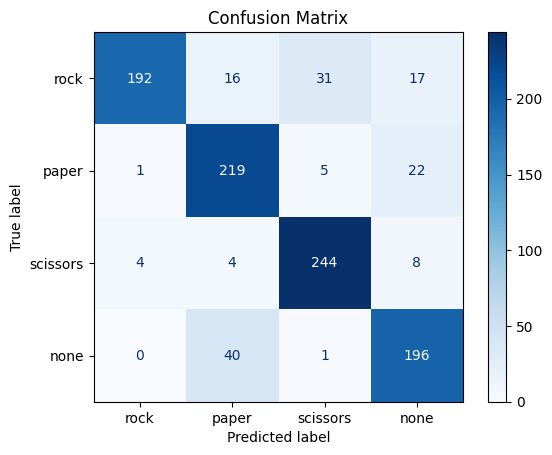

In [131]:
# Accuracy
accuracy = accuracy_score(true_numeric, max_classes)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(true_numeric, max_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(mapping.keys()))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Accuracy (threshold applied): 0.3970 (39.70%)


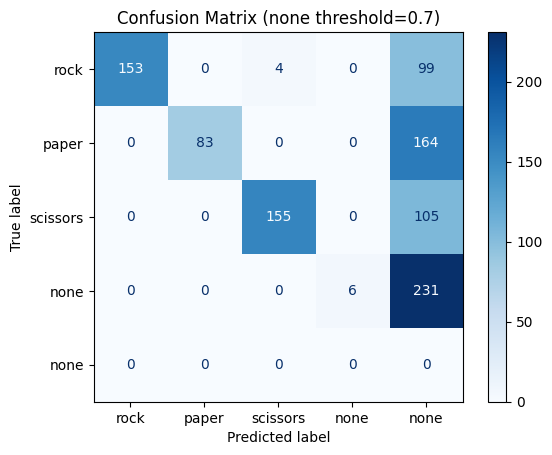

In [132]:
# ------------------------
# Accuracy (threshold applied)
# ------------------------
accuracy_thresh = accuracy_score(true_numeric, pred_classes_thresh)
print(f"Accuracy (threshold applied): {accuracy_thresh:.4f} ({accuracy_thresh*100:.2f}%)")

# ------------------------
# Confusion Matrix with 'none'
# ------------------------
all_labels = list(mapping.keys()) + ['none']  # Include 'none' class

cm_thresh = confusion_matrix(true_numeric, pred_classes_thresh, labels=range(len(all_labels)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_thresh, display_labels=all_labels)
disp.plot(cmap='Blues', xticks_rotation='horizontal')
plt.title(f"Confusion Matrix (none threshold={conf_thres})")
plt.show()

# Evaluation



  FOLD 1 / 5
  Epoch: 0 | Train Loss: 2.54289, Train Acc: 24.43% | Test Loss: 1.47631, Test Acc: 29.61%
  Epoch: 100 | Train Loss: 1.05731, Train Acc: 50.77% | Test Loss: 0.93198, Test Acc: 59.56%
  Epoch: 200 | Train Loss: 0.93670, Train Acc: 64.57% | Test Loss: 0.83173, Test Acc: 70.61%
  Epoch: 300 | Train Loss: 0.92947, Train Acc: 63.61% | Test Loss: 0.79448, Test Acc: 67.84%
  Epoch: 400 | Train Loss: 0.82998, Train Acc: 68.18% | Test Loss: 0.65096, Test Acc: 79.69%
  Epoch: 499 | Train Loss: 0.78225, Train Acc: 69.96% | Test Loss: 0.60497, Test Acc: 82.72%

  FOLD 2 / 5
  Epoch: 0 | Train Loss: 2.81092, Train Acc: 25.42% | Test Loss: 1.97938, Test Acc: 27.36%
  Epoch: 100 | Train Loss: 1.06041, Train Acc: 58.28% | Test Loss: 0.94229, Test Acc: 68.48%
  Epoch: 200 | Train Loss: 0.90393, Train Acc: 66.38% | Test Loss: 0.80129, Test Acc: 72.83%
  Epoch: 300 | Train Loss: 0.92006, Train Acc: 61.64% | Test Loss: 0.73408, Test Acc: 72.71%
  Epoch: 400 | Train Loss: 0.79394, Train Acc:

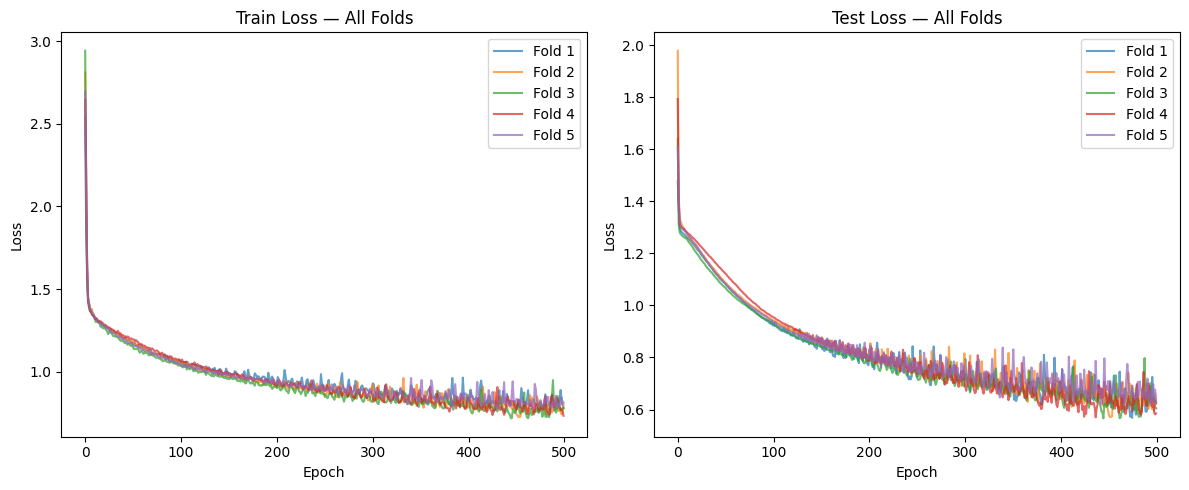


  K-FOLD RESULTS SUMMARY
  Fold 1: Train 69.96%  |  Test 82.72%
  Fold 2: Train 68.59%  |  Test 79.87%
  Fold 3: Train 69.53%  |  Test 80.25%
  Fold 4: Train 72.90%  |  Test 84.45%
  Fold 5: Train 67.39%  |  Test 79.05%

  Mean test acc : 81.27%
  Std  test acc : 2.01%


In [133]:
torch.manual_seed(42)

all_train_losses = [] # Initialize to store epoch-wise train losses for each fold
all_test_losses  = [] # This will now store epoch-wise test losses for each fold

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_train_accs = [] # Initialize to store final train accuracy for each fold
fold_test_accs = [] # This will store final test accuracy for each fold
X_np = X.numpy()
y_np = y.numpy()

for fold, (train_idx, test_idx) in enumerate(skf.split(X_np, y_np)):
    print(f"\n{'='*40}")
    print(f"  FOLD {fold + 1} / {N_FOLDS}")
    print(f"{'='*40}")

    # Split data for the current fold
    X_train_fold, y_train_fold = X[train_idx].to(device), y[train_idx].long().to(device)
    X_test_fold, y_test_fold   = X[test_idx].to(device), y[test_idx].long().to(device)

    # Create a new model for each fold to ensure independent training
    model = RPSModel(input_features=input_features,
                     output_features=classes).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1) # Optimizer needs to be re-initialized too

    train_losses_per_epoch_fold = [] # To store losses for current fold's training
    test_losses_per_epoch_fold = []  # To store losses for current fold's testing
    current_fold_train_acc = 0.0
    current_fold_test_acc = 0.0

    for epoch in range(EPOCHS): # Use EPOCHS from ablation cell
        ### Training
        model.train()
        y_logits = model(X_train_fold)
        y_pred = torch.argmax(y_logits, dim=1)
        loss = loss_fn(y_logits, y_train_fold)
        current_fold_train_acc = accuracy_fn(y_true=y_train_fold, y_pred=y_pred)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### Testing (evaluation during training for this fold)
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test_fold)
            test_pred = torch.argmax(test_logits, dim=1)
            test_loss = loss_fn(test_logits, y_test_fold)
            current_fold_test_acc = accuracy_fn(y_true=y_test_fold, y_pred=test_pred)

        train_losses_per_epoch_fold.append(loss.item())
        test_losses_per_epoch_fold.append(test_loss.item())

        if epoch % 100 == 0 or epoch == EPOCHS - 1: # Print less frequently
            print(f"  Epoch: {epoch} | Train Loss: {loss:.5f}, Train Acc: {current_fold_train_acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {current_fold_test_acc:.2f}%")

    # After training for all epochs in a fold, store the epoch-wise losses and final accuracies
    all_train_losses.append(train_losses_per_epoch_fold)
    all_test_losses.append(test_losses_per_epoch_fold)

    fold_train_accs.append(current_fold_train_acc) # acc from last epoch of training
    fold_test_accs.append(current_fold_test_acc) # test_acc from last epoch of testing

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i, losses in enumerate(all_train_losses):
    plt.plot(losses, label=f'Fold {i+1}', alpha=0.7)
plt.title('Train Loss — All Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
for i, losses in enumerate(all_test_losses):
    plt.plot(losses, label=f'Fold {i+1}', alpha=0.7)
plt.title('Test Loss — All Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n{'='*40}")
print(f"  K-FOLD RESULTS SUMMARY")
print(f"{'='*40}")
for i, (tr, te) in enumerate(zip(fold_train_accs, fold_test_accs)):
    print(f"  Fold {i+1}: Train {tr:.2f}%  |  Test {te:.2f}%")
print(f"\n  Mean test acc : {np.mean(fold_test_accs):.2f}%")
print(f"  Std  test acc : {np.std(fold_test_accs):.2f}%")

# Which features are the most important?

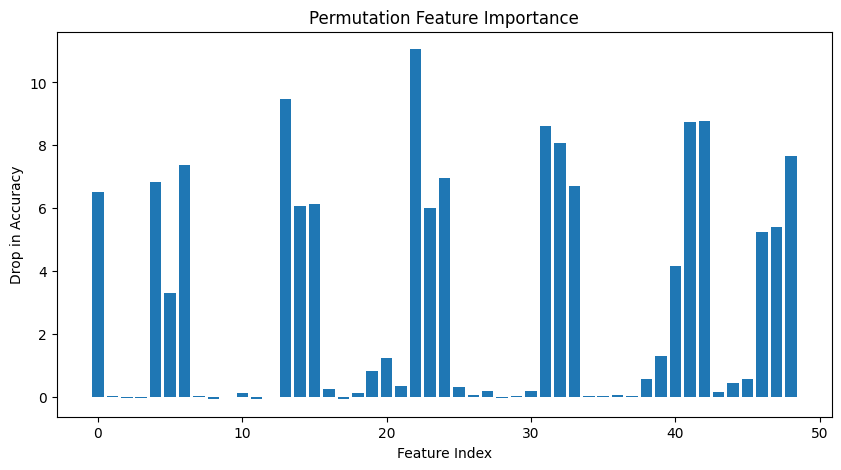

In [134]:
baseline_acc = accuracy_fn(y_true=y_test, y_pred=torch.argmax(model_4(X_test), dim=1))

importances = []
for i in range(X_test.shape[1]):
    X_permuted = X_test.clone()
    X_permuted[:, i] = X_test[torch.randperm(X_test.shape[0]), i]  # shuffle column i

    with torch.inference_mode():
        perm_pred = torch.argmax(model_4(X_permuted), dim=1)

    perm_acc = accuracy_fn(y_true=y_test, y_pred=perm_pred)
    importances.append(baseline_acc - perm_acc)  # drop in accuracy = importance

# Plot
plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances)
plt.xlabel("Feature Index")
plt.ylabel("Drop in Accuracy")
plt.title("Permutation Feature Importance")
plt.show()

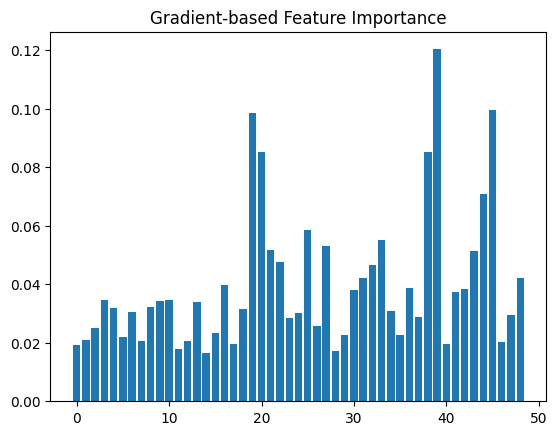

In [135]:
X_test.requires_grad_(True)
output = model_4(X_test)
output.max(dim=1).values.sum().backward()

importances = X_test.grad.abs().mean(dim=0).cpu().detach()

plt.bar(range(len(importances)), importances)
plt.title("Gradient-based Feature Importance")
plt.show()